# Module 10: Gradient-boosted trees vs. OLS on 1-year-ahead ROA

Same target/features as Module 9 (1-year-ahead ROA on current-year ratios plus SIC industry dummies), but fit with XGBoost and evaluated against the Module 9 OLS baseline on an identical time-based train/test split (train: fyear <= 2020, test: fyear >= 2021).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from notebooks.m9_ols import RATIO_FEATURES, build_dataset
from src.models.gbm import fit_gbm
from src.models.ols import fit_ols
from src.schema import FundamentalsSchema

DATA_PATH = REPO_ROOT / "data" / "raw" / "fundamentals.parquet"
RESULTS_DIR = REPO_ROOT / "results" / "m10"

/home/zhuwei/Projects/accy575/ACCY575-wrds-data-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load, validate, and build features

Reuses `build_dataset` from Module 9 so the target/features (1-year-ahead ROA; `revt/at`, `xrd/at`, `oancf/at`; 2-digit SIC dummies) are identical, not just similar, between the two modules.

In [2]:
df = pd.read_parquet(DATA_PATH)
FundamentalsSchema.validate(df, lazy=True)

df, features = build_dataset(df)
print(f"{len(df)} rows, {len(features)} features ({len(features) - len(RATIO_FEATURES)} industry dummies)")

7461 rows, 65 features (62 industry dummies)


## Time-based split

`fit_gbm` carves its own validation slice (last two years of whatever `train` it's given) for early stopping, so `train` here only needs to exclude `test` — no separate val split at this level.

In [3]:
train = df[df["fyear"] <= 2020]
test = df[df["fyear"] >= 2021]

print(f"train: {len(train)} rows (fyear {train['fyear'].min()}-{train['fyear'].max()})")
print(f"test:  {len(test)} rows (fyear {test['fyear'].min()}-{test['fyear'].max()})")

# Both models are scored on the identical set of test rows, dropping any
# row missing the target or a feature — otherwise XGBoost's native NaN
# handling would let it evaluate on more rows than OLS can, which isn't
# an apples-to-apples comparison.
test_eval = test.dropna(subset=["target", *features])
print(f"test rows usable for scoring: {len(test_eval)}")

train: 5469 rows (fyear 2010-2020)
test:  1992 rows (fyear 2021-2024)
test rows usable for scoring: 1447


## Fit GBM

In [4]:
gbm_model, gbm_preds = fit_gbm(train, test_eval, target="target", features=features)

gbm_rmse = mean_squared_error(test_eval["target"], gbm_preds) ** 0.5
gbm_r2 = r2_score(test_eval["target"], gbm_preds)
print(f"GBM  test RMSE: {gbm_rmse:.4f}")
print(f"GBM  test R2:   {gbm_r2:.4f}")

fit_gbm: dropped 219 of 5469 train rows with NaN target


GBM  test RMSE: 0.0577
GBM  test R2:   0.4735


## OLS baseline (same split)

Refits Module 9's `fit_ols` on this notebook's `train` only (not the full 2010–2024 sample it used in Module 9), so the comparison below is on identical training data and identical test rows.

In [5]:
ols_results = fit_ols(train, target="target", features=features)

X_test_ols = sm.add_constant(test_eval[features].astype("float64"), has_constant="add")
X_test_ols = X_test_ols[ols_results.model.exog_names]  # match training column order
ols_preds = ols_results.predict(X_test_ols)

ols_rmse = mean_squared_error(test_eval["target"], ols_preds) ** 0.5
ols_r2 = r2_score(test_eval["target"], ols_preds)
print(f"OLS  test RMSE: {ols_rmse:.4f}")
print(f"OLS  test R2:   {ols_r2:.4f}")

print()
print(f"{'model':<6}{'RMSE':>10}{'R2':>10}")
print(f"{'GBM':<6}{gbm_rmse:>10.4f}{gbm_r2:>10.4f}")
print(f"{'OLS':<6}{ols_rmse:>10.4f}{ols_r2:>10.4f}")

fit_ols: dropped 221 of 5469 rows with NaN in target/features
OLS  test RMSE: 0.0578
OLS  test R2:   0.4717

model       RMSE        R2
GBM       0.0577    0.4735
OLS       0.0578    0.4717


## SHAP summary plot (test set)

SHAP summary plot written to /home/zhuwei/Projects/accy575/ACCY575-wrds-data-analysis/results/m10/shap_summary.png


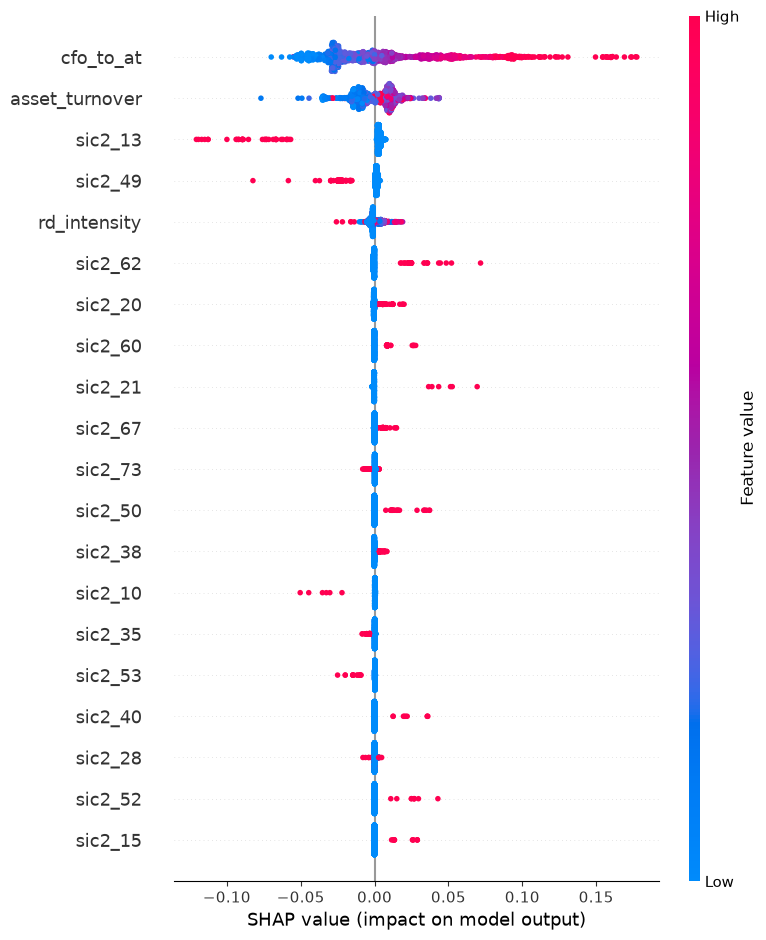

In [6]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

explainer = shap.TreeExplainer(gbm_model)
shap_values = explainer(test_eval[features])

shap.summary_plot(shap_values, test_eval[features], show=False)
plt.gcf().savefig(RESULTS_DIR / "shap_summary.png", bbox_inches="tight")
print(f"SHAP summary plot written to {RESULTS_DIR / 'shap_summary.png'}")

**Interpreting SHAP values**: SHAP values decompose each prediction into per-feature contributions that sum to the model's deviation from the average prediction. They're an attribution tool, not a causal one. A SHAP value of +0.02 for `rd_intensity` on firm *i* does not mean "if firm *i* raised R&D intensity by one unit, ROA would be 0.02 higher." It means "given what the model has learned, firm *i*'s R&D intensity is contributing +0.02 to the model's prediction relative to the average firm." For causal claims, OLS with an identification strategy — or the causal-ML methods you won't see until graduate work — is what you reach for.

## Robustness: different random seed

Re-fits GBM with `random_state=7` instead of the default (`None`) to check whether the result depends on the particular random draw.

In [7]:
_, gbm_preds_seed7 = fit_gbm(train, test_eval, target="target", features=features, params={"random_state": 7})

gbm_rmse_seed7 = mean_squared_error(test_eval["target"], gbm_preds_seed7) ** 0.5
gbm_r2_seed7 = r2_score(test_eval["target"], gbm_preds_seed7)

print(f"GBM, default seed:  RMSE={gbm_rmse:.4f}  R2={gbm_r2:.4f}")
print(f"GBM, random_state=7: RMSE={gbm_rmse_seed7:.4f}  R2={gbm_r2_seed7:.4f}")

fit_gbm: dropped 219 of 5469 train rows with NaN target


GBM, default seed:  RMSE=0.0577  R2=0.4735
GBM, random_state=7: RMSE=0.0577  R2=0.4735


**The result is byte-identical across seeds** (RMSE and R² match to 4 decimal places). This isn't a coincidence: `random_state` only matters when `subsample` or `colsample_bytree` are below 1.0 (i.e. when trees are built from bootstrapped rows/columns); our `DEFAULT_PARAMS` never sets either, so both default to 1.0 and every tree sees the full training data deterministically. With no sampling randomness in the training procedure, there's nothing for the seed to perturb — the "robustness check" here confirms determinism rather than stability under randomness.

## Robustness: shorter training window

Refits both models on train = 2015–2020 only (test unchanged at 2021–2024), to check whether GBM's parity with OLS depends on having the full 2010–2020 training window.

In [8]:
train_short = df[(df["fyear"] >= 2015) & (df["fyear"] <= 2020)]
print(f"train_short: {len(train_short)} rows (fyear {train_short['fyear'].min()}-{train_short['fyear'].max()})")

_, gbm_preds_short = fit_gbm(train_short, test_eval, target="target", features=features)
gbm_rmse_short = mean_squared_error(test_eval["target"], gbm_preds_short) ** 0.5
gbm_r2_short = r2_score(test_eval["target"], gbm_preds_short)

ols_results_short = fit_ols(train_short, target="target", features=features)
X_test_ols_short = sm.add_constant(test_eval[features].astype("float64"), has_constant="add")
X_test_ols_short = X_test_ols_short[ols_results_short.model.exog_names]
ols_preds_short = ols_results_short.predict(X_test_ols_short)
ols_rmse_short = mean_squared_error(test_eval["target"], ols_preds_short) ** 0.5
ols_r2_short = r2_score(test_eval["target"], ols_preds_short)

print()
print(f"{'model':<20}{'train window':<16}{'RMSE':>10}{'R2':>10}")
print(f"{'GBM':<20}{'2010-2020':<16}{gbm_rmse:>10.4f}{gbm_r2:>10.4f}")
print(f"{'GBM':<20}{'2015-2020':<16}{gbm_rmse_short:>10.4f}{gbm_r2_short:>10.4f}")
print(f"{'OLS':<20}{'2010-2020':<16}{ols_rmse:>10.4f}{ols_r2:>10.4f}")
print(f"{'OLS':<20}{'2015-2020':<16}{ols_rmse_short:>10.4f}{ols_r2_short:>10.4f}")

train_short: 2980 rows (fyear 2015-2020)
fit_gbm: dropped 130 of 2980 train rows with NaN target


fit_ols: dropped 131 of 2980 rows with NaN in target/features

model               train window          RMSE        R2
GBM                 2010-2020           0.0577    0.4735
GBM                 2015-2020           0.0594    0.4427
OLS                 2010-2020           0.0578    0.4717
OLS                 2015-2020           0.0582    0.4654


**GBM degrades more than OLS on the shorter window.** With the full 2010–2020 window GBM edges out OLS (R² 0.4735 vs 0.4717); with only 2015–2020 (~2,850 usable rows, roughly half) that flips — OLS actually beats GBM (R² 0.4654 vs 0.4427). This is consistent with one of the hypotheses for why GBM wasn't beating OLS by more in the first place: a linear model's fixed functional form is more sample-efficient and degrades gracefully with less data, while a tree ensemble needs more rows to reliably learn nonlinear structure and loses ground first when data is scarce.